In [20]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
import matplotlib.pyplot as plt

# Cargar los datos desde Demanda.csv
data = pd.read_csv("Demanda.csv")

# Eliminar columnas innecesarias (Fecha y Hora incluidas)
if 'Unnamed: 10' in data.columns:
    data = data.drop("Unnamed: 10", axis=1)

# Limpiar nombres de columnas
data.columns = data.columns.str.strip()

# Mostrar las primeras filas antes de eliminar Fecha y Hora
print("Datos originales:")
print(data.head())

# Eliminar columnas de 'Fecha' y 'Hora'
data = data.drop(['Fecha', 'Hora'], axis=1)

# Mostrar las primeras filas después de eliminar Fecha y Hora
print("\nDatos después de eliminar las columnas 'Fecha' y 'Hora':")
print(data.head())

# Ajustar nombre de la columna 'Día de la semana'
data['Dia de la semana'] = data['Dia de la semana'].str.strip().replace("Miercoles", "Miércoles")

# Crear la variable objetivo 'Feriado' basada en 'Eventos especiales'
data['Feriado'] = data['Eventos especiales']

# Seleccionar las variables predictoras (X) y la variable objetivo (y)
X = data[['Flujo de personas', 'Flujo de choferes', 'Feriado', 'Eventos inesperados', 'Dia de la semana']]
y = data['Numero de pasajeros']

# Convertir la columna 'Dia de la semana' en valores numéricos
X['Dia de la semana'] = X['Dia de la semana'].replace({
    'Lunes': 1, 'Martes': 2, 'Miércoles': 3, 'Jueves': 4, 'Viernes': 5, 'Sábado': 6, 'Domingo': 7
})

# Dividir el dataset en conjuntos de entrenamiento y prueba (80% - 20%)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar las características (normalización)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


Datos originales:
       Fecha  Hora   Parada  Numero de pasajeros  Eventos especiales  \
0  4/22/2024  6:00  Obrajes                    2                   0   
1  4/22/2024  6:15  Obrajes                    0                   0   
2  4/22/2024  6:30  Obrajes                    0                   0   
3  4/22/2024  6:45  Obrajes                    2                   0   
4  4/22/2024  7:00  Obrajes                    3                   0   

  Dia de la semana  Flujo de personas  Flujo de choferes  Eventos inesperados  \
0            Lunes                  6                  2                    0   
1            Lunes                  4                  2                    0   
2            Lunes                  4                  4                    0   
3            Lunes                  5                  6                    0   
4            Lunes                  4                  9                    0   

  Clima  
0   sol  
1   sol  
2   sol  
3   sol  
4   sol  

D

C:\Users\OMEN\AppData\Local\Temp\ipykernel_6632\4016916697.py:42: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X['Dia de la semana'] = X['Dia de la semana'].replace({
C:\Users\OMEN\AppData\Local\Temp\ipykernel_6632\4016916697.py:42: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X['Dia de la semana'] = X['Dia de la semana'].replace({


In [21]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Definir el modelo de Red Neuronal Densa mejorado
model = Sequential()

# Capa de entrada y primera capa oculta con Dropout
model.add(Dense(128, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dropout(0.2))  # Dropout para evitar sobreajuste

# Segunda capa oculta con Dropout
model.add(Dense(64, activation='relu'))
model.add(Dropout(0.2))  # Dropout

# Tercera capa oculta
model.add(Dense(32, activation='relu'))

# Capa de salida
model.add(Dense(1))  # Predicción del número de pasajeros

# Compilar el modelo mejorado con el optimizador Adam y una tasa de aprendizaje ajustada
model.compile(optimizer=Adam(learning_rate=0.001), loss='mean_squared_error', metrics=['mae'])

# Entrenar el modelo mejorado
history = model.fit(X_train_scaled, y_train, epochs=100, batch_size=32, validation_split=0.2, verbose=1)


Epoch 1/100


c:\Python312\Lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


82/82 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 45.2510 - mae: 4.4672 - val_loss: 22.7861 - val_mae: 3.6070
Epoch 2/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 18.6156 - mae: 3.2722 - val_loss: 19.6326 - val_mae: 3.1954
Epoch 3/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.6132 - mae: 3.0131 - val_loss: 18.9263 - val_mae: 3.1094
Epoch 4/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.7537 - mae: 2.9258 - val_loss: 18.7795 - val_mae: 3.0644
Epoch 5/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.9521 - mae: 3.0110 - val_loss: 18.9185 - val_mae: 3.0549
Epoch 6/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 17.5312 - mae: 2.9432 - val_loss: 18.4616 - val_mae: 3.0465
Epoch 7/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 16.1723 - mae: 2.8685 - val_loss: 18.7451 - val_mae: 3.0293
Epoch 8/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 15.7634 - mae: 2.8816 - val_loss: 18.4477 - val_mae: 3.0128
Epoch 9/100
82/82 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1

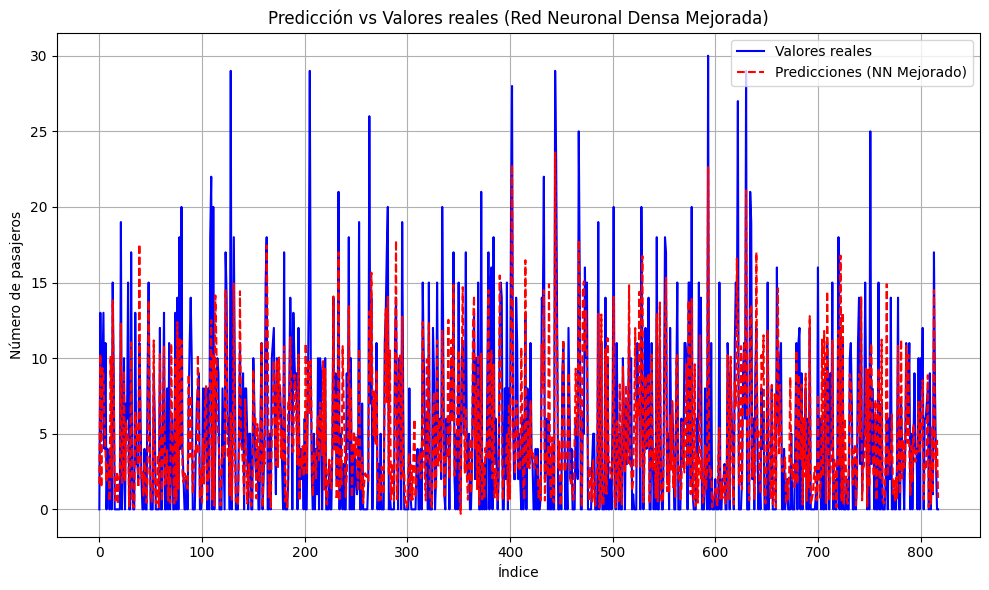

In [22]:
import matplotlib.pyplot as plt

# Graficar predicciones vs valores reales
plt.figure(figsize=(10, 6))
plt.plot(y_test.values, label='Valores reales', color='blue')
plt.plot(y_pred_nn, label='Predicciones (NN Mejorado)', color='red', linestyle='--')
plt.title('Predicción vs Valores reales (Red Neuronal Densa Mejorada)')
plt.xlabel('Índice')
plt.ylabel('Número de pasajeros')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


In [23]:
from sklearn.metrics import r2_score

# Calcular R² en el conjunto de prueba
r2 = r2_score(y_test, y_pred_nn)
print(f"Coeficiente de determinación R²: {r2}")


Coeficiente de determinación R²: 0.5957582592964172
